This notebook demonstrates a simple linear regression analysis using [Python/R] to model Salary based on Years of Experience.

In [6]:
library(ggplot2)

filename <- "../regression_data.csv"
x_column <- "YearsExperience"
y_column <- "Salary"

dataset <- read.csv(filename)

head(dataset)

,YearsExperience,Salary
,<dbl>,<dbl>
1,1.1,39343
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.9,56642


Fit the regression model

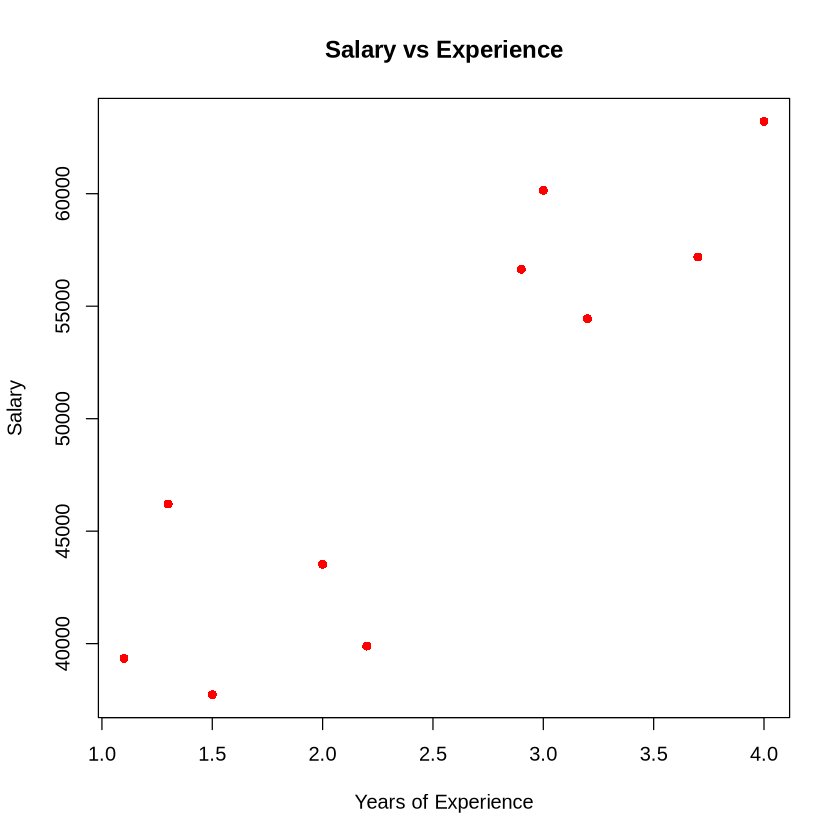

In [8]:
plot(
  dataset$YearsExperience,
  dataset$Salary,
  col = "red",
  pch = 16,
  xlab = "Years of Experience",
  ylab = "Salary",
  main = "Salary vs Experience"
)

In [ ]:
Predict the salary

In [10]:
years_to_predict <- 6

prediction_input <- data.frame(
  YearsExperience = years_to_predict
)

predicted_salary <- predict(
  model,
  newdata = prediction_input
)

predicted_salary

1 
78915.28

Plot

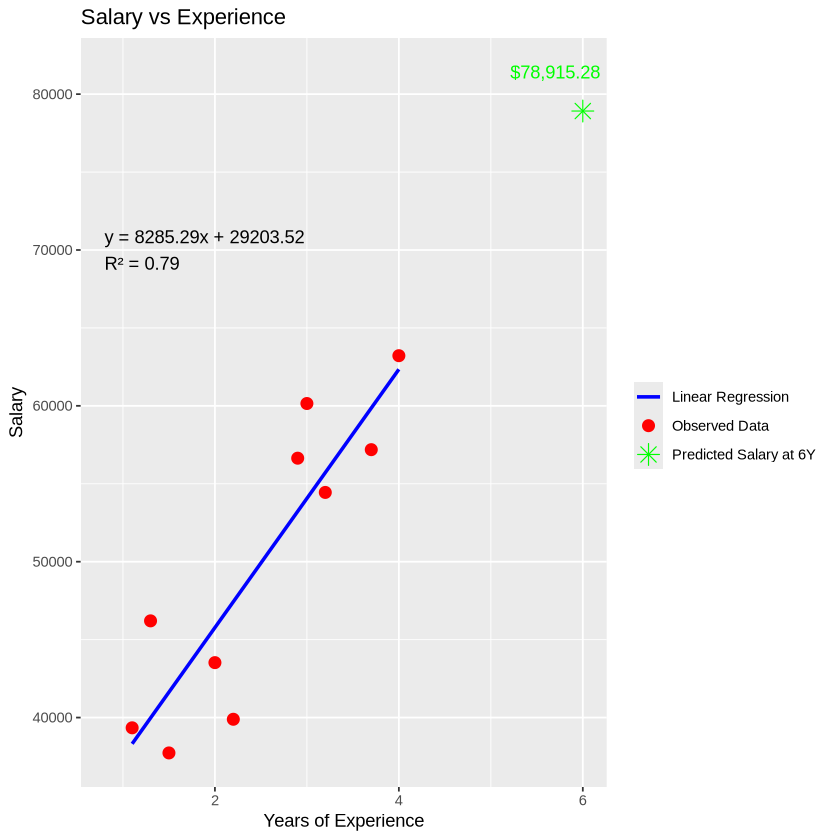

In [16]:
prediction_data <- data.frame(
  YearsExperience = years_to_predict,
  Salary = predicted_salary
)

ggplot() +

  geom_point(
    aes(
      x = dataset$YearsExperience,
      y = dataset$Salary,
      colour = "Observed Data"
    ),
    size = 3
  ) +

  geom_line(
    aes(
      x = dataset$YearsExperience,
      y = predictions,
      colour = "Linear Regression"
    ),
    linewidth = 1
  ) +

  geom_point(
    data = prediction_data,
    aes(
      x = YearsExperience,
      y = Salary,
      colour = "Predicted Salary at 6Y"
    ),
    shape = 8,
    size = 4
  ) +

  annotate(
    "text",
    x = years_to_predict - 0.3,
    y = predicted_salary + 2500,
    label = paste0(
      "$",
      format(round(predicted_salary,2),
             big.mark=",",
             nsmall=2)
    ),
    colour = "green"
  ) +

  annotate(
    "text",
    x = 0.8,
    y = 70000,
    hjust = 0,
    label = paste0(
      "y = ",
      round(slope,2),
      "x + ",
      round(intercept,2),
      "\nR² = ",
      round(r_squared,2)
    )
  ) +

  scale_colour_manual(
    name = "",
    values = c(
      "Observed Data" = "red",
      "Linear Regression" = "blue",
      "Predicted Salary at 6Y" = "green"
    )
  ) +

  ggtitle("Salary vs Experience") +
  xlab("Years of Experience") +
  ylab("Salary")

In [14]:
model <- lm(
  Salary ~ YearsExperience,
  data = dataset
)

predictions <- predict(model)

slope <- coef(model)[2]
intercept <- coef(model)[1]
r_squared <- summary(model)$r.squared

summary(model)


Call:
lm(formula = Salary ~ YearsExperience, data = dataset)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407
